# Lab 4 & 5: Forward and Backward Propagation in Neural Network

**Name:** Anzal Azam Shaikh  
**Roll No:** 24108106  
**Program/Section:** BSAI 5A

This notebook completes all five tasks given at the end of the lab manual using Google Colab.


## Setup: Import Libraries and Load MNIST

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("training images:", len(train_dataset))
print("test images:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.61MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.74MB/s]

training images: 60000
test images: 10000


## Visualize Sample Images

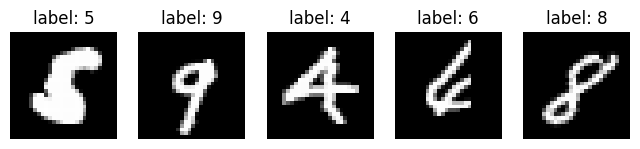

In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1000, shuffle=False
)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(8, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i][0], cmap="gray")
    ax.set_title(f"label: {labels[i].item()}")
    ax.axis("off")
plt.show()

## Model Definition

In [ ]:
class Model(nn.Module):
    def __init__(self, in_features=784, hidden=128, out_features=10,
                 activation="relu", second_hidden=False):
        super().__init__()

        self.second_hidden = second_hidden
        self.activation_name = activation

        self.fc1 = nn.Linear(in_features, hidden)

        if second_hidden:
            self.fc_hidden2 = nn.Linear(hidden, 64)
            self.fc2 = nn.Linear(64, out_features)
        else:
            self.fc2 = nn.Linear(hidden, out_features)

    def activate(self, x):
        if self.activation_name == "relu":
            return torch.relu(x)
        elif self.activation_name == "sigmoid":
            return torch.sigmoid(x)
        elif self.activation_name == "tanh":
            return torch.tanh(x)
        else:
            raise ValueError("Unknown activation")

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.activate(self.fc1(x))

        if self.second_hidden:
            x = self.activate(self.fc_hidden2(x))

        x = self.fc2(x)
        return x

## Helper Function for Training and Testing

This function is used to keep the experiments consistent. It performs:

1. Forward pass
2. Loss calculation
3. Backpropagation
4. Optimizer update

It also records average loss and test accuracy.


In [ ]:
def train_and_evaluate(hidden=128, epochs=3, activation="relu",
                        optimizer_name="Adam", lr=0.001,
                        second_hidden=False):
    torch.manual_seed(0)

    model = Model(
        hidden=hidden,
        activation=activation,
        second_hidden=second_hidden
    )

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    else:
        raise ValueError("Unknown optimizer")

    losses = []
    start_time = time.time()

    for epoch in range(epochs):
        total_loss = 0.0

        for images, labels in train_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)

        print(f"epoch {epoch + 1} | avg loss {avg_loss:.4f}")

    training_time = time.time() - start_time

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total

    return model, losses, accuracy, training_time

# Task 1 — Change Hidden Neurons: 32 and 256

**Question:** How does test accuracy change? How does training time change?

We compare the original 128 neurons with 32 and 256 neurons.


In [ ]:
task1_results = []

for hidden in [32, 128, 256]:
    print(f"\n--- Hidden neurons = {hidden} ---")
    model, losses, accuracy, training_time = train_and_evaluate(
        hidden=hidden,
        epochs=3,
        activation="relu",
        optimizer_name="Adam",
        lr=0.001
    )

    task1_results.append({
        "Hidden neurons": hidden,
        "Test accuracy": accuracy,
        "Training time (seconds)": training_time
    })

for result in task1_results:
    print(
        f"Hidden={result['Hidden neurons']}: "
        f"Accuracy={result['Test accuracy']:.4f}, "
        f"Time={result['Training time (seconds)']:.2f}s"
    )


--- Hidden neurons = 32 ---
epoch 1 | avg loss 0.4741
epoch 2 | avg loss 0.2454
epoch 3 | avg loss 0.1967

--- Hidden neurons = 128 ---
epoch 1 | avg loss 0.3437
epoch 2 | avg loss 0.1566
epoch 3 | avg loss 0.1095

--- Hidden neurons = 256 ---
epoch 1 | avg loss 0.3073
epoch 2 | avg loss 0.1299
epoch 3 | avg loss 0.0845
Hidden=32: Accuracy=0.9476, Time=25.57s
Hidden=128: Accuracy=0.9686, Time=28.18s
Hidden=256: Accuracy=0.9713, Time=32.82s


### Task 1 Observation

- 32 hidden neurons make the network smaller, so training generally requires less computation, but the model has less capacity.
- 256 hidden neurons make the network larger, so training generally takes more computation/time and gives the model more capacity.
- The **exact accuracy and time should be taken from the Colab output above**, because the lab manual asks for an experimental comparison rather than giving fixed values.


# Task 2 — Increase Epochs from 3 to 10

**Question:** Does the loss keep decreasing, or does it plateau?


epoch 1 | avg loss 0.3437
epoch 2 | avg loss 0.1566
epoch 3 | avg loss 0.1095
epoch 4 | avg loss 0.0832
epoch 5 | avg loss 0.0655
epoch 6 | avg loss 0.0535
epoch 7 | avg loss 0.0439
epoch 8 | avg loss 0.0361
epoch 9 | avg loss 0.0294
epoch 10 | avg loss 0.0243


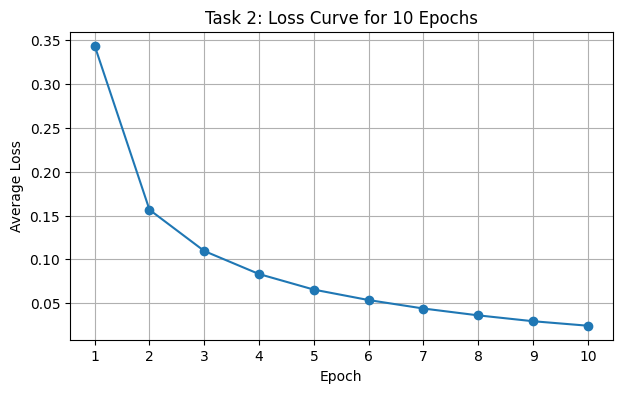

Final test accuracy: 0.9760


In [ ]:
model_10, losses_10, accuracy_10, time_10 = train_and_evaluate(
    hidden=128,
    epochs=10,
    activation="relu",
    optimizer_name="Adam",
    lr=0.001
)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), losses_10, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Task 2: Loss Curve for 10 Epochs")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print(f"Final test accuracy: {accuracy_10:.4f}")

### Task 2 Observation

Check the loss curve. If the decrease becomes very small after some epochs, the loss is **plateauing**. The exact point of plateau should be identified from the graph produced in Colab.


# Task 3 — Replace ReLU with Sigmoid and Tanh

**Question:** Does training speed or final accuracy change?

We compare:
- ReLU
- Sigmoid
- Tanh


In [ ]:
task3_results = []

for activation in ["relu", "sigmoid", "tanh"]:
    print(f"\n--- Activation = {activation} ---")

    model, losses, accuracy, training_time = train_and_evaluate(
        hidden=128,
        epochs=3,
        activation=activation,
        optimizer_name="Adam",
        lr=0.001
    )

    task3_results.append({
        "Activation": activation,
        "Final loss": losses[-1],
        "Test accuracy": accuracy,
        "Training time (seconds)": training_time
    })

for result in task3_results:
    print(
        f"{result['Activation']}: "
        f"Final loss={result['Final loss']:.4f}, "
        f"Accuracy={result['Test accuracy']:.4f}, "
        f"Time={result['Training time (seconds)']:.2f}s"
    )


--- Activation = relu ---
epoch 1 | avg loss 0.3437
epoch 2 | avg loss 0.1566
epoch 3 | avg loss 0.1095

--- Activation = sigmoid ---
epoch 1 | avg loss 0.5260
epoch 2 | avg loss 0.2316
epoch 3 | avg loss 0.1793

--- Activation = tanh ---
epoch 1 | avg loss 0.3404
epoch 2 | avg loss 0.1677
epoch 3 | avg loss 0.1181
relu: Final loss=0.1095, Accuracy=0.9686, Time=27.95s
sigmoid: Final loss=0.1793, Accuracy=0.9494, Time=27.39s
tanh: Final loss=0.1181, Accuracy=0.9650, Time=27.09s


### Task 3 Observation

Compare the three Colab results. Different activation functions can change both optimization/training behavior and final accuracy. Use the measured values above as the experimental answer.


# Task 4 — Change Adam to SGD

**Question:** Compare the loss curve of SGD with the Adam version.

The lab specifies SGD with learning rate **0.01**.


epoch 1 | avg loss 1.2160
epoch 2 | avg loss 0.4927
epoch 3 | avg loss 0.3934
epoch 1 | avg loss 0.3437
epoch 2 | avg loss 0.1566
epoch 3 | avg loss 0.1095


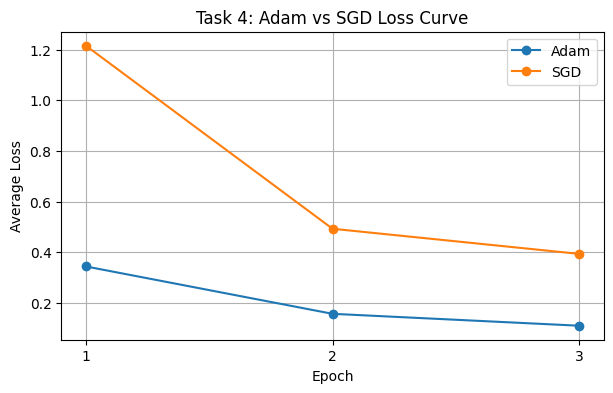

Adam accuracy: 0.9686
SGD accuracy: 0.9014


In [ ]:
model_sgd, losses_sgd, accuracy_sgd, time_sgd = train_and_evaluate(
    hidden=128,
    epochs=3,
    activation="relu",
    optimizer_name="SGD",
    lr=0.01
)

# Adam baseline with the same 3 epochs
model_adam, losses_adam, accuracy_adam, time_adam = train_and_evaluate(
    hidden=128,
    epochs=3,
    activation="relu",
    optimizer_name="Adam",
    lr=0.001
)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 4), losses_adam, marker="o", label="Adam")
plt.plot(range(1, 4), losses_sgd, marker="o", label="SGD")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Task 4: Adam vs SGD Loss Curve")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

print(f"Adam accuracy: {accuracy_adam:.4f}")
print(f"SGD accuracy: {accuracy_sgd:.4f}")

### Task 4 Observation

Use the graph to compare how quickly the loss decreases.

- Adam uses adaptive parameter updates.
- SGD uses standard stochastic gradient descent with the specified learning rate of 0.01.
- The graph and printed accuracy provide the experimental comparison required by the task.


# Task 5 — Add a Second Hidden Layer

**Question:** Does accuracy improve?

Architecture:

**784 → 128 → 64 → 10**


In [ ]:
model_2hidden, losses_2hidden, accuracy_2hidden, time_2hidden = train_and_evaluate(
    hidden=128,
    epochs=3,
    activation="relu",
    optimizer_name="Adam",
    lr=0.001,
    second_hidden=True
)

print(f"Two-hidden-layer model accuracy: {accuracy_2hidden:.4f}")

# Compare with the original one-hidden-layer model
model_1hidden, losses_1hidden, accuracy_1hidden, time_1hidden = train_and_evaluate(
    hidden=128,
    epochs=3,
    activation="relu",
    optimizer_name="Adam",
    lr=0.001,
    second_hidden=False
)

print(f"One-hidden-layer model accuracy: {accuracy_1hidden:.4f}")
print(f"Accuracy difference: {accuracy_2hidden - accuracy_1hidden:+.4f}")

epoch 1 | avg loss 0.3583
epoch 2 | avg loss 0.1539
epoch 3 | avg loss 0.1043
Two-hidden-layer model accuracy: 0.9691
epoch 1 | avg loss 0.3437
epoch 2 | avg loss 0.1566
epoch 3 | avg loss 0.1095
One-hidden-layer model accuracy: 0.9686
Accuracy difference: +0.0005


### Task 5 Observation

Compare the two printed accuracies.

- One hidden layer: **784 → 128 → 10**
- Two hidden layers: **784 → 128 → 64 → 10**

If the two-hidden-layer accuracy is higher, accuracy improved in this experiment. If it is lower, it did not improve. The lab asks us to test this experimentally, so the Colab result is the final answer.


Why# Final Task Summary

| Task | Experiment |
|---|---|
| 1 | Hidden neurons: 32 vs 128 vs 256 |
| 2 | Epochs: 3 vs 10 and inspect loss plateau |
| 3 | ReLU vs Sigmoid vs Tanh |
| 4 | Adam vs SGD (SGD lr = 0.01) |
| 5 | One hidden layer vs two hidden layers |